In [42]:
import pandas as pd
from sqlalchemy import create_engine, text

engine = create_engine("mysql+pymysql://root:@localhost/climate_watch")

df_test = pd.read_sql("SELECT * FROM GlobalLandTemperaturesByCity LIMIT 5", engine)
df_test


tables = [
    "GlobalLandTemperaturesByCity",
    "GlobalLandTemperaturesByCountry",
    "GlobalLandTemperaturesByMajorCity",
    "GlobalLandTemperaturesByState",
    "globaltemperatures"
]

with engine.connect() as conn:
    for table in tables:
        subset_table = f"{table}_subset"
        
        conn.execute(text(f"DROP TABLE IF EXISTS {subset_table}"))
        conn.execute(text(f"""
            CREATE TABLE {subset_table} AS
            SELECT *
            FROM {table}
            WHERE YEAR(dt) >= 1980;
        """))
        
        print(f"Klaar: {subset_table}")

conn.commit()

Klaar: GlobalLandTemperaturesByCity_subset
Klaar: GlobalLandTemperaturesByCountry_subset
Klaar: GlobalLandTemperaturesByMajorCity_subset
Klaar: GlobalLandTemperaturesByState_subset
Klaar: globaltemperatures_subset


In [113]:



# 1. Load original CSV correctly
df = pd.read_csv("/Applications/XAMPP/xamppfiles/htdocs/climate-watch/ClimateData/GlobalLandTemperaturesByCountry.csv")

# 2. Clean columns
df["dt"] = pd.to_datetime(df["dt"], errors="coerce")
df["AverageTemperature"] = pd.to_numeric(df["AverageTemperature"], errors="coerce")
df["Country"] = df["Country"].str.strip()

# 3. Fix specific known country-name issue if needed
#df["Country"] = df["Country"].replace({
 #   "Bonaire, Saint Eustatius And Saba": "Bonaire - Saint Eustatius and Saba"
#})

# 4. Check the result
#print(df[df["Country"].str.contains("Bonaire", na=False)])


# 3. Make subset
before_1980_temp = df[df["dt"].dt.year < 1980].copy()
df_subset = df[df["dt"].dt.year >= 1980].copy()

# 4. Check
print(df.shape)
print(df_subset.shape)
print(df_subset["Country"].nunique())
df["dt"] = pd.to_datetime(df["dt"])


# 4. Fill missing per country (ON subset 👈)
df_subset["AverageTemperature"] = (
    df_subset["AverageTemperature"]
    .fillna(df_subset.groupby("Country")["AverageTemperature"].transform("mean"))
)

# 5. Average per country
country_avg = (
    df_subset
    .groupby("Country", as_index=False)["AverageTemperature"]
    .mean()
)

# 6. Top 10
top_hot = country_avg.sort_values("AverageTemperature", ascending=False).head(10)
top_cold = country_avg.sort_values("AverageTemperature", ascending=True).head(10)

(577462, 4)
(98415, 4)
243


In [115]:
before_1980_temp = df[df["dt"].dt.year < 1980].copy()

before_trend = (
    before_1980_temp.groupby("year")["AverageTemperature"]
    .mean()
    .reset_index()
)

KeyError: 'year'

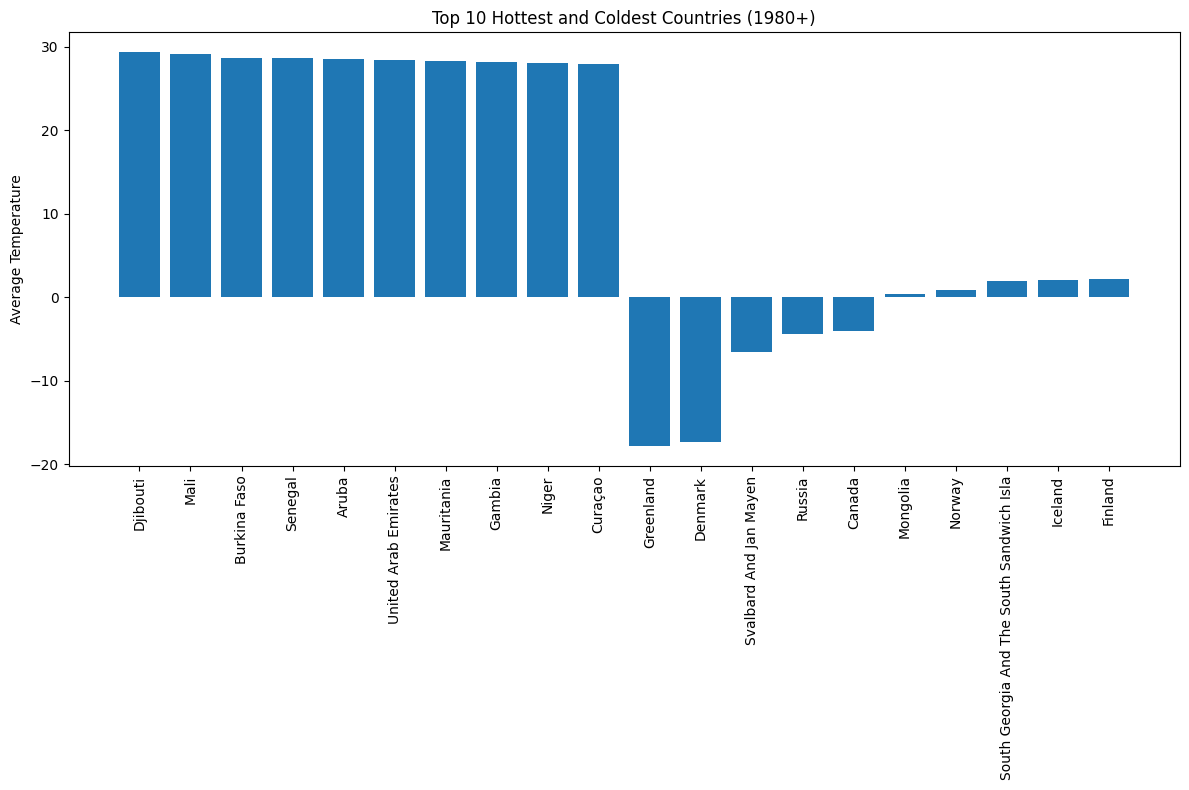

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

# combine both
top_hot["Type"] = "Hottest"
top_cold["Type"] = "Coldest"
combined = pd.concat([top_hot, top_cold])

# plot
plt.figure(figsize=(12, 8))
plt.bar(combined["Country"], combined["AverageTemperature"])
plt.xticks(rotation=90)
plt.ylabel("Average Temperature")
plt.title("Top 10 Hottest and Coldest Countries (1980+)")
plt.tight_layout()
plt.show()

In [45]:
# 1. Load original CSV correctly
df = pd.read_csv("/Applications/XAMPP/xamppfiles/htdocs/climate-watch/ClimateData/GlobalLandTemperaturesByCity.csv")

# 2. Clean columns
df["dt"] = pd.to_datetime(df["dt"], errors="coerce")
df["AverageTemperature"] = pd.to_numeric(df["AverageTemperature"], errors="coerce")
df["AverageTemperatureUncertainty"] = pd.to_numeric(df["AverageTemperatureUncertainty"], errors="coerce")
df["Country"] = df["Country"].str.strip()
df["City"] = df["City"].str.strip()

# 3. Make subset for city data
df_city_subset = df[df["dt"].dt.year >= 1980].copy()

# 4. Check
print(df.shape)
print(df_city_subset.shape)
print(df_city_subset["Country"].nunique())
print(df_city_subset["City"].nunique())
df["dt"] = pd.to_datetime(df["dt"])


# 4. Fill missing per country (ON subset 👈)
df_city_subset["AverageTemperature"] = (
    df_city_subset["AverageTemperature"]
    .fillna(df_city_subset.groupby("City")["AverageTemperature"].transform("mean"))
)

# 5. Average per country
city_avg = (
    df_city_subset
    .groupby(["City", "Country", "Latitude", "Longitude"], as_index=False)["AverageTemperature"]
    .mean()
)

# 6. Top 10
top_hot_city = city_avg.sort_values("AverageTemperature", ascending=False).head(10)
top_cold_city = city_avg.sort_values("AverageTemperature", ascending=True).head(10)

print("Top 10 Hottest Cities:")
print(top_hot_city)              
print("\nTop 10 Coldest Cities:")
print(top_cold_city)

(8599212, 7)
(1421550, 7)
159
3448
Top 10 Hottest Cities:
            City   Country Latitude Longitude  AverageTemperature
1397      Jibuti  Djibouti   12.05N    42.74E           29.721559
3215  Umm Durman     Sudan   15.27N    32.50E           29.652307
1539    Khartoum     Sudan   15.27N    32.50E           29.652307
2140      Niamey     Niger   13.66N     2.48E           29.630797
1499     Kassala     Sudan   15.27N    35.83E           29.486295
2008       Mopti      Mali   15.27N     4.17W           29.425166
2527       Rabak     Sudan   13.66N    32.20E           29.135139
1655       Kusti     Sudan   13.66N    32.20E           29.135139
1829      Madras     India   13.66N    80.09E           29.041574
91      Ambattur     India   13.66N    80.09E           29.041574

Top 10 Coldest Cities:
                     City   Country Latitude Longitude  AverageTemperature
2168              Norilsk    Russia   69.92N    88.83E          -10.802074
1659                Kyzyl    Russia   52.2

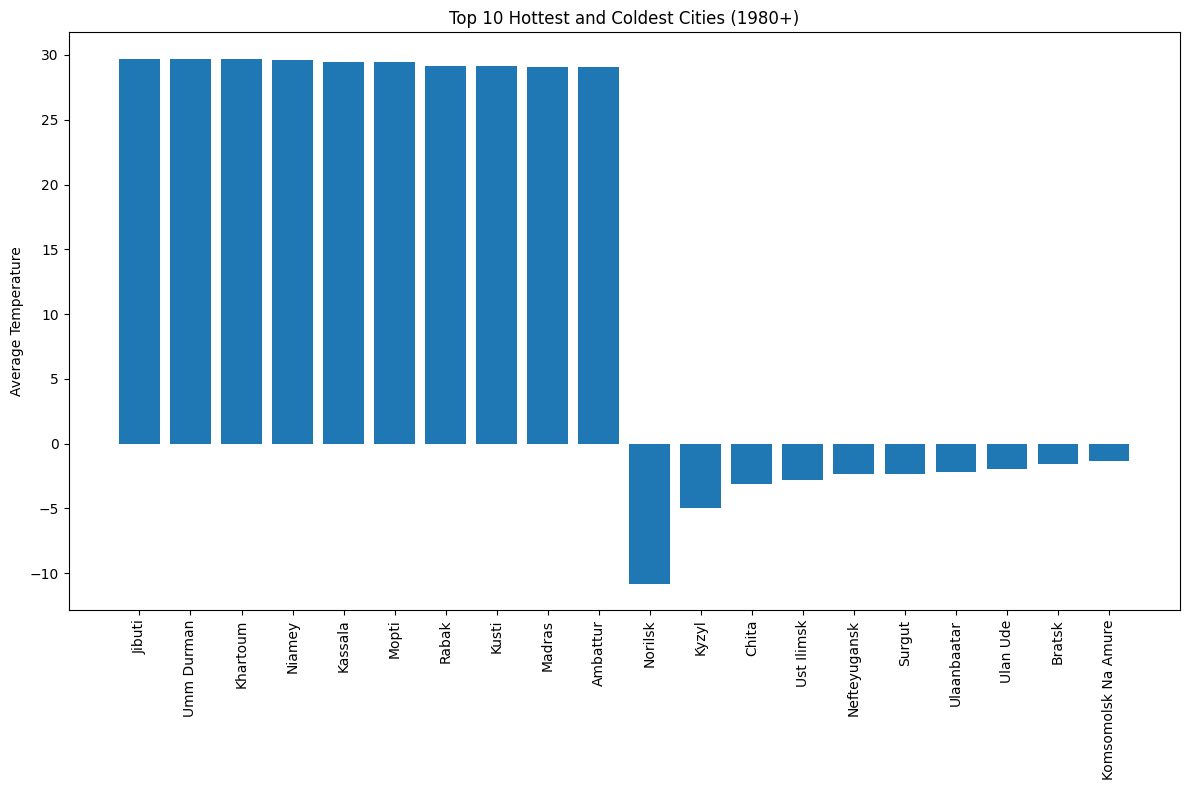

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

# combine both
top_hot["Type"] = "Hottest"
top_cold["Type"] = "Coldest"
combined = pd.concat([top_hot_city, top_cold_city])

# plot
plt.figure(figsize=(12, 8))
plt.bar(combined["City"], combined["AverageTemperature"])
plt.xticks(rotation=90)
plt.ylabel("Average Temperature")
plt.title("Top 10 Hottest and Coldest Cities (1980+)")
plt.tight_layout()
plt.show()

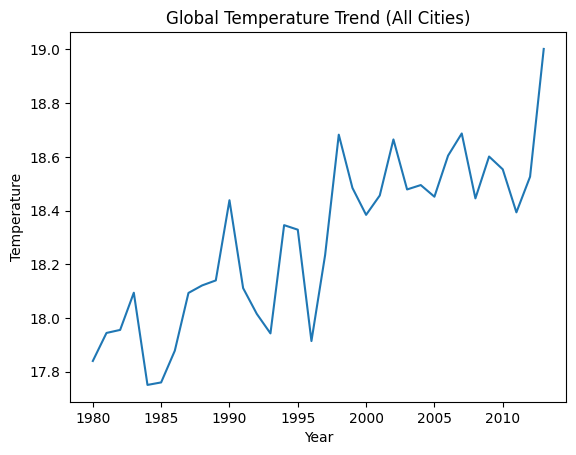

In [50]:
df_city_subset["year"] = df_city_subset["dt"].dt.year

# Gemiddelde over ALLE steden per jaar
global_trend = (
    df_city_subset.groupby("year")["AverageTemperature"]
    .mean()
    .reset_index()
)

# Plot
plt.plot(global_trend["year"], global_trend["AverageTemperature"])
plt.title("Global Temperature Trend (All Cities)")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

In [51]:
city_yearly = (
    df_city_subset
    .groupby(["year", "City", "Country"], as_index=False)["AverageTemperature"]
    .mean()
)

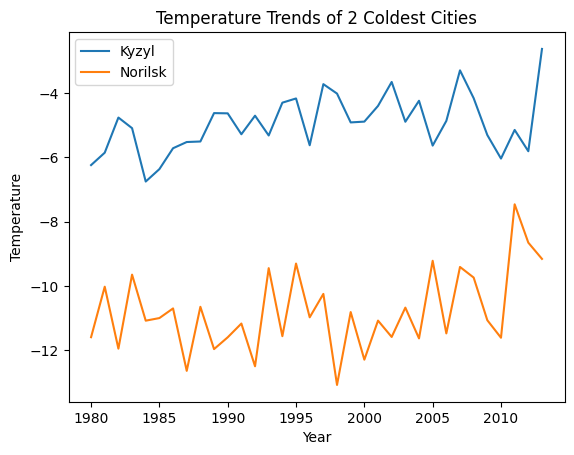

In [52]:
import matplotlib.pyplot as plt

# take only top 2
top_2_cold = top_cold_city.head(2)

subset = city_yearly[
    city_yearly["City"].isin(top_2_cold["City"])
]

for city in subset["City"].unique():
    data = subset[subset["City"] == city]
    plt.plot(data["year"], data["AverageTemperature"], label=city)

plt.legend()
plt.title("Temperature Trends of 2 Coldest Cities")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()


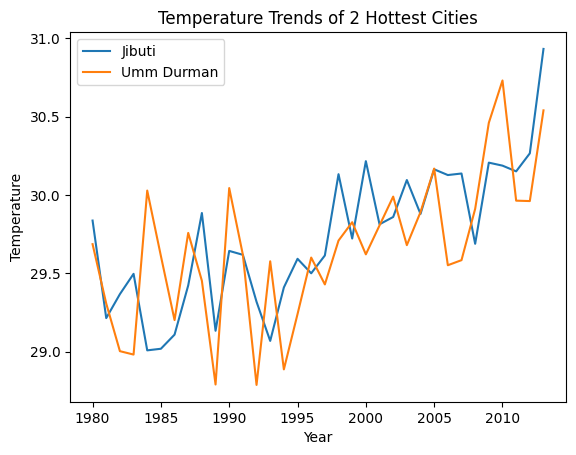

In [53]:
import matplotlib.pyplot as plt

# take only top 2
top_2_hot = top_hot_city.head(2)

subset = city_yearly[
    city_yearly["City"].isin(top_2_hot["City"])
]

for city in subset["City"].unique():
    data = subset[subset["City"] == city]
    plt.plot(data["year"], data["AverageTemperature"], label=city)

plt.legend()
plt.title("Temperature Trends of 2 Hottest Cities")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

plt.show()

In [54]:
city_extremes = (
    df_city_subset.groupby("City")["AverageTemperature"]
    .agg(["min", "max"])
    .reset_index()
)

# verschil berekenen
city_extremes["range"] = city_extremes["max"] - city_extremes["min"]


top_variable = city_extremes.sort_values("range", ascending=False).head(10)
bottom_variable = city_extremes.sort_values("range", ascending=True).head(10)

print("Top 10 cities with the largest temperature range:")
print(top_variable[["City", "min", "max", "range"]])
print("\nBottom 10 cities with the smallest temperature range:")
print(bottom_variable[["City", "min", "max", "range"]])

Top 10 cities with the largest temperature range:
                 City     min     max   range
3361           Yichun -25.568  30.589  56.157
2122   Nizhnevartovsk -34.846  21.039  55.885
2134          Norilsk -38.447  16.382  54.829
2898           Surgut -33.730  20.729  54.459
2080     Nefteyugansk -33.730  20.729  54.459
3172       Ust Ilimsk -33.250  21.082  54.332
1635            Kyzyl -35.758  17.519  53.277
390   Blagoveshchensk -28.462  23.435  51.897
1150            Heihe -28.462  23.435  51.897
2745          Seversk -29.968  21.584  51.552

Bottom 10 cities with the smallest temperature range:
            City     min     max  range
1830      Manado  25.614  27.726  2.112
385       Bitung  25.614  27.726  2.112
3023     Ternate  25.938  28.070  2.132
1036   Gorontalo  25.750  28.018  2.268
2386   Pontianak  25.918  28.204  2.286
294     Baturaja  24.458  26.955  2.497
2413  Prabumulih  24.458  26.955  2.497
1919       Metro  25.254  27.752  2.498
2420   Pringsewu  25.254  27.

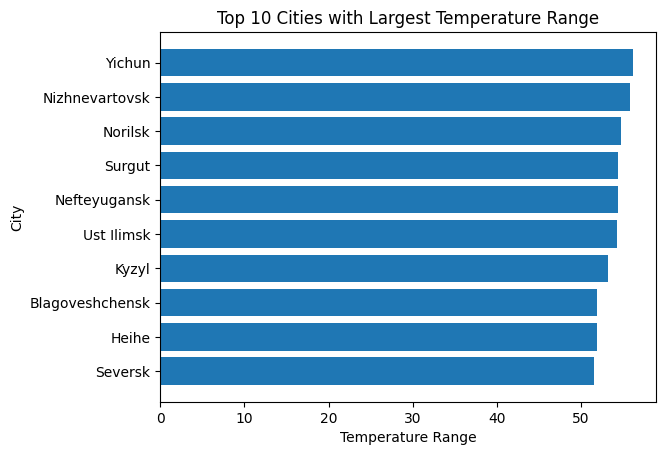

In [55]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(top_variable["City"], top_variable["range"])
plt.xlabel("Temperature Range")
plt.ylabel("City")
plt.title("Top 10 Cities with Largest Temperature Range")
plt.gca().invert_yaxis()
plt.show()

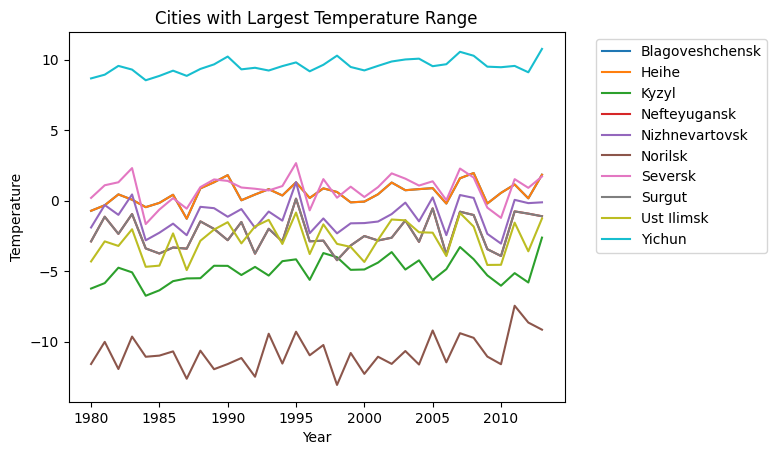

In [56]:
import matplotlib.pyplot as plt

subset = city_yearly[
    city_yearly["City"].isin(top_variable["City"])
]

for city in subset["City"].unique():
    data = subset[subset["City"] == city]
    plt.plot(data["year"], data["AverageTemperature"], label=city)

plt.legend(bbox_to_anchor=(1.05, 1))
plt.title("Cities with Largest Temperature Range")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

In [57]:
# 1. Load original CSV correctly
df = pd.read_csv("/Applications/XAMPP/xamppfiles/htdocs/climate-watch/ClimateData/GlobalLandTemperaturesByMajorCity.csv")

# 2. Clean columns
df["dt"] = pd.to_datetime(df["dt"], errors="coerce")
df["AverageTemperature"] = pd.to_numeric(df["AverageTemperature"], errors="coerce")
df["AverageTemperatureUncertainty"] = pd.to_numeric(df["AverageTemperatureUncertainty"], errors="coerce")
df["Country"] = df["Country"].str.strip()
df["City"] = df["City"].str.strip()

# 3. Make subset for city data
df_major_city_subset = df[df["dt"].dt.year >= 1980].copy()

# 4. Check
print(df.shape)
print(df_major_city_subset.shape)
print(df_major_city_subset["Country"].nunique())
print(df_major_city_subset["City"].nunique())
df["dt"] = pd.to_datetime(df["dt"])


# 4. Fill missing per country (ON subset 👈)
df_major_city_subset["AverageTemperature"] = (
    df_major_city_subset["AverageTemperature"]
    .fillna(df_major_city_subset.groupby("City")["AverageTemperature"].transform("mean"))
)

# 5. Average per country
city_avg = (
    df_major_city_subset
    .groupby("City", as_index=False)["AverageTemperature"]
    .mean()
)

# 6. Top 10
top_major_hot_city = city_avg.sort_values("AverageTemperature", ascending=False).head(10)
top_major_cold_city = city_avg.sort_values("AverageTemperature", ascending=True).head(10)

print("Top 10 Hottest Cities:")
print(top_major_hot_city)              
print("\nTop 10 Coldest Cities:")
print(top_major_cold_city)

(239177, 7)
(40500, 7)
49
100
Top 10 Hottest Cities:
                City  AverageTemperature
97        Umm Durman           29.652307
57            Madras           29.041574
42            Jiddah           28.242493
35  Ho Chi Minh City           27.770054
8            Bangkok           27.765322
63         Mogadishu           27.672478
30         Fortaleza           27.638399
36         Hyderabad           27.477592
87          Surabaya           27.412795
75           Rangoon           27.332765

Top 10 Coldest Cities:
                City  AverageTemperature
34            Harbin            4.732978
79  Saint Petersburg            4.922995
65            Moscow            5.170673
64          Montreal            5.569536
19         Changchun            5.984960
81          Santiago            6.297983
96           Toronto            6.807879
48              Kiev            8.042911
85          Shenyang            8.153666
92           Taiyuan            8.801297


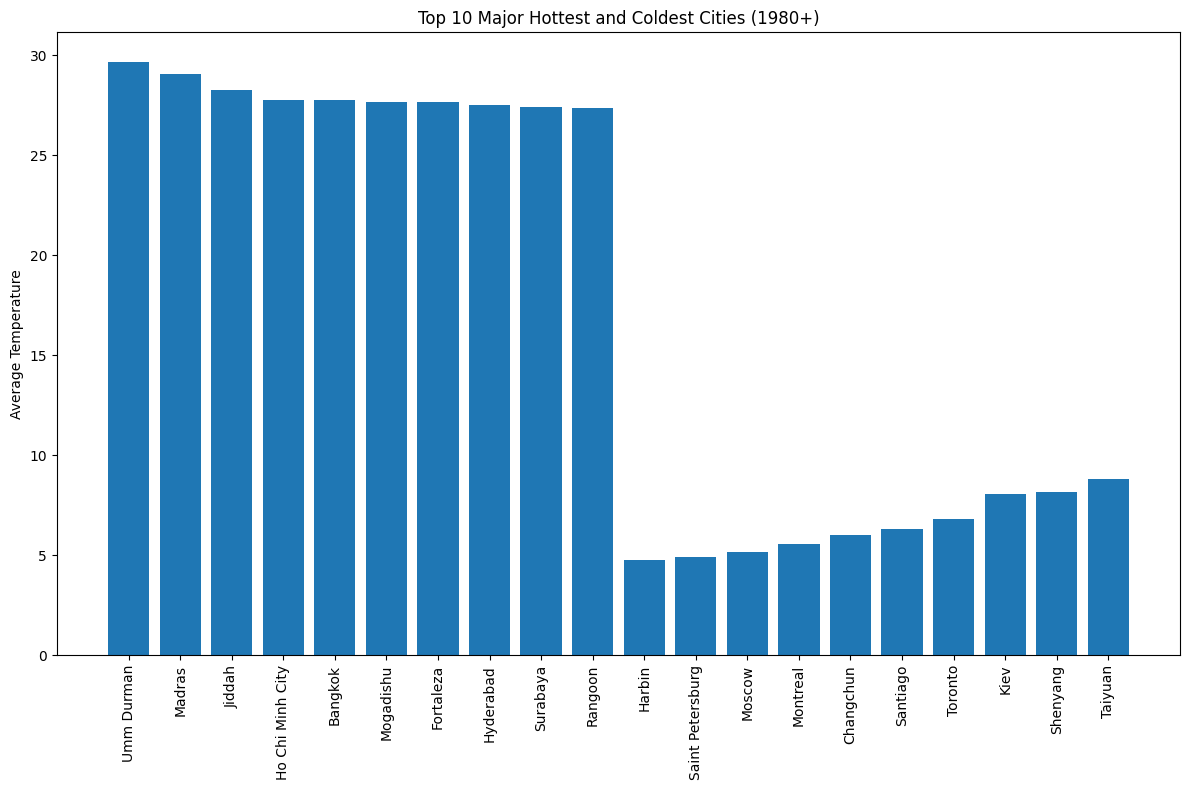

In [58]:
import matplotlib.pyplot as plt
import pandas as pd

# combine both
top_major_hot_city["Type"] = "Hottest"
top_major_cold_city["Type"] = "Coldest"
combined = pd.concat([top_major_hot_city, top_major_cold_city])

# plot
plt.figure(figsize=(12, 8))
plt.bar(combined["City"], combined["AverageTemperature"])
plt.xticks(rotation=90)
plt.ylabel("Average Temperature")
plt.title("Top 10 Major Hottest and Coldest Cities (1980+)")
plt.tight_layout()
plt.show()

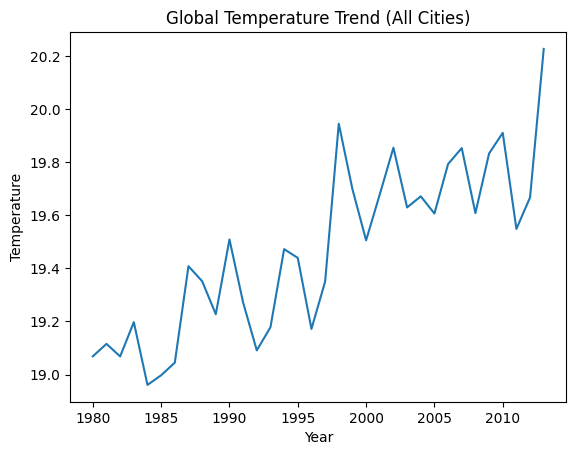

In [59]:
df_major_city_subset["year"] = df_major_city_subset["dt"].dt.year

# Gemiddelde over ALLE steden per jaar
global_trend = (
    df_major_city_subset.groupby("year")["AverageTemperature"]
    .mean()
    .reset_index()
)

# Plot
plt.plot(global_trend["year"], global_trend["AverageTemperature"])
plt.title("Global Temperature Trend (All Cities)")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

In [60]:
# 1. Load original CSV correctly
df = pd.read_csv("/Applications/XAMPP/xamppfiles/htdocs/climate-watch/ClimateData/GlobalTemperatures.csv")

# 2. Clean columns
# 1. Date
df["dt"] = pd.to_datetime(df["dt"], errors="coerce")

# 2. Numeric columns
cols = [
    "LandAverageTemperature",
    "LandAverageTemperatureUncertainty",
    "LandMaxTemperature",
    "LandMaxTemperatureUncertainty",
    "LandMinTemperature",
    "LandMinTemperatureUncertainty",
    "LandAndOceanAverageTemperature",
    "LandAndOceanAverageTemperatureUncertainty"
]

for col in cols:
       df[col] = pd.to_numeric(df[col], errors="coerce")


In [61]:

df[cols].describe()

,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
count,3180.000000,3180.000000,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000
mean,8.374731,0.938468,14.350601,0.479782,2.743595,0.431849,15.212566,0.128532
std,4.381310,1.096440,4.309579,0.583203,4.155835,0.445838,1.274093,0.073587
min,-2.080000,0.034000,5.900000,0.044000,-5.407000,0.045000,12.475000,0.042000
25%,4.312000,0.186750,10.212000,0.142000,-1.334500,0.155000,14.047000,0.063000
50%,8.610500,0.392000,14.760000,0.252000,2.949500,0.279000,15.251000,0.122000
75%,12.548250,1.419250,18.451500,0.539000,6.778750,0.458250,16.396250,0.151000
max,19.021000,7.880000,21.320000,4.373000,9.715000,3.498000,17.611000,0.457000


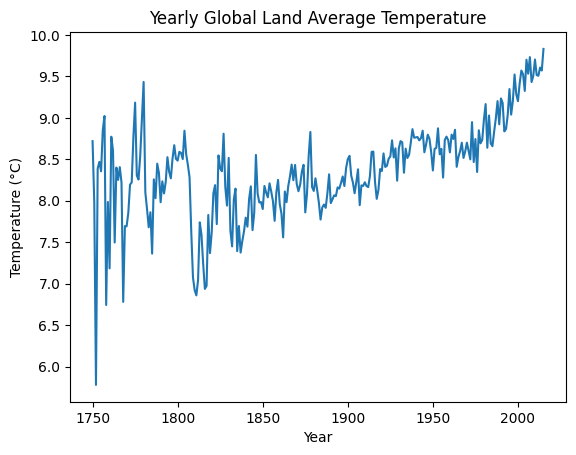

In [62]:
import matplotlib.pyplot as plt

# Create year column
df["year"] = df["dt"].dt.year

# Group by year (global average)
yearly = (
    df.groupby("year")["LandAverageTemperature"]
    .mean()
    .reset_index()
)

# Plot
plt.figure()
plt.plot(yearly["year"], yearly["LandAverageTemperature"])

plt.title("Yearly Global Land Average Temperature")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.show()

In [116]:
before_1980 = yearly[yearly["year"] < 1980]
after_1980 = yearly[yearly["year"] >= 1980]

In [117]:
print("Before 1980 average temperature:")
print(before_1980["LandAverageTemperature"].mean())

print("After 1980 average temperature:")
print(after_1980["LandAverageTemperature"].mean())

Before 1980 average temperature:
8.2300148833051
After 1980 average temperature:
9.25945138888889


In [121]:
import numpy as np

slope_before = np.polyfit(
    before_1980["year"],
    before_1980["LandAverageTemperature"],
    1
)[0]

trend_before = np.poly1d(slope_before)

slope_after = np.polyfit(
    after_1980["year"],
    after_1980["LandAverageTemperature"],
    1
)[0]

trend_after = np.poly1d(slope_after)

print("Slope before 1980:", slope_before)
print("Slope after 1980:", slope_after)

Slope before 1980: 0.0030143144229904826
Slope after 1980: 0.02654430501930498


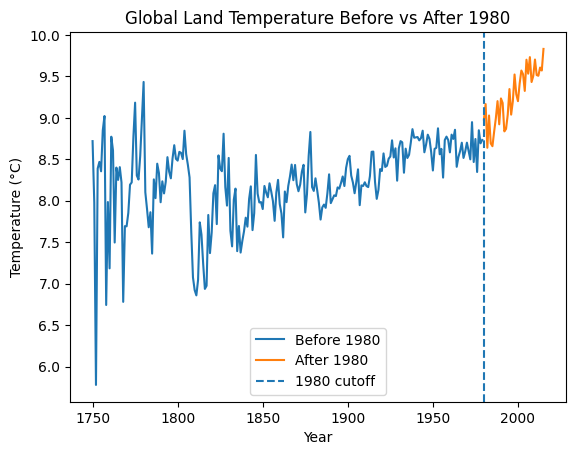

In [122]:
plt.figure()

plt.plot(before_1980["year"], before_1980["LandAverageTemperature"], label="Before 1980")
plt.plot(after_1980["year"], after_1980["LandAverageTemperature"], label="After 1980")

plt.axvline(1980, linestyle="--", label="1980 cutoff")

plt.title("Global Land Temperature Before vs After 1980")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

IndexError: invalid index to scalar variable.

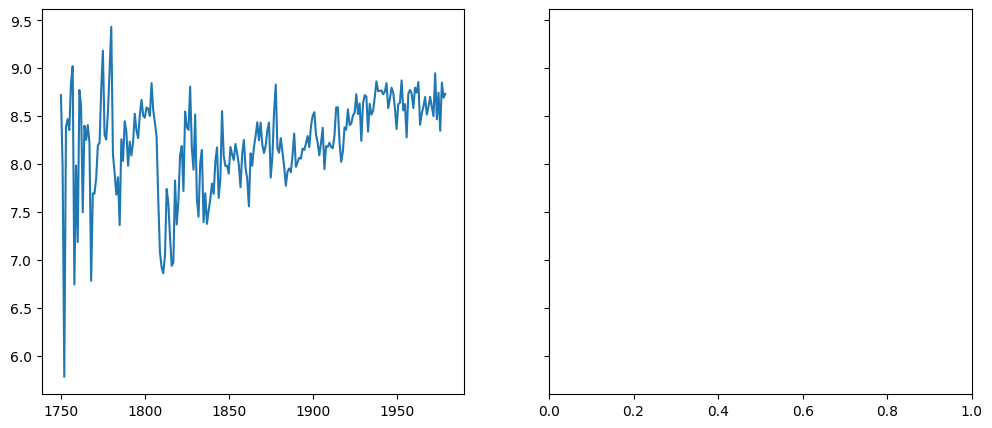

In [124]:
# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Before 1980 plot
axes[0].plot(before_1980["year"], before_1980["LandAverageTemperature"], label="Temperature")
axes[0].plot(
    before_1980["year"],
    trend_before(before_1980["year"]),
    linestyle="--",
    label=f"Slope = {slope_before[0]:.4f}"
)
axes[0].set_title("Before 1980")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Temperature (°C)")
axes[0].legend()

# After 1980 plot
axes[1].plot(after_1980["year"], after_1980["LandAverageTemperature"], label="Temperature")
axes[1].plot(
    after_1980["year"],
    trend_after(after_1980["year"]),
    linestyle="--",
    label=f"Slope = {slope_after[0]:.4f}"
)
axes[1].set_title("After 1980")
axes[1].set_xlabel("Year")
axes[1].legend()

# Final layout
plt.suptitle("Temperature Trends Before vs After 1980")
plt.tight_layout()
plt.show()

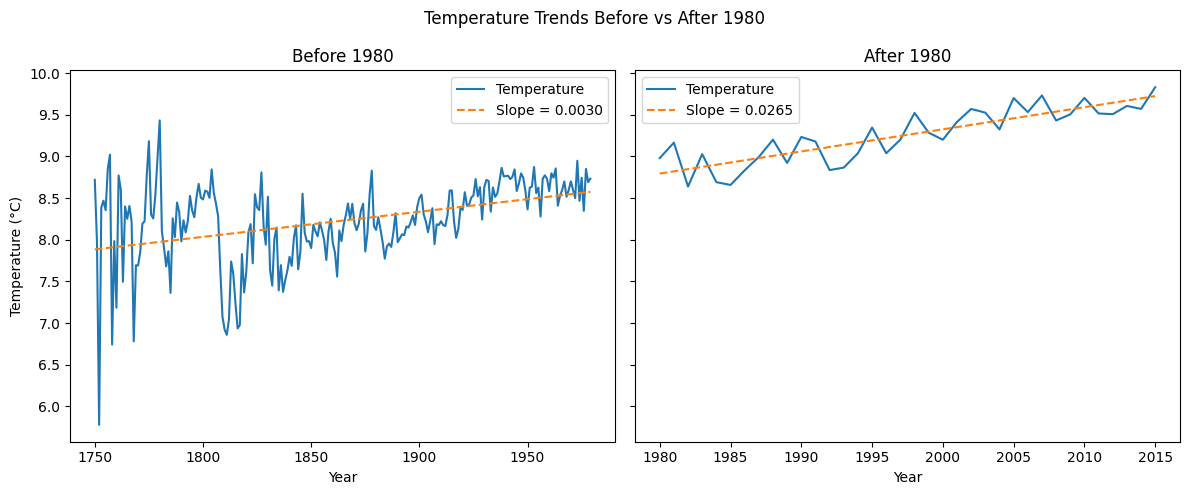

In [125]:
import numpy as np
import matplotlib.pyplot as plt

# Split data
before_1980 = yearly[yearly["year"] < 1980]
after_1980 = yearly[yearly["year"] >= 1980]

# Fit trend lines
coef_before = np.polyfit(before_1980["year"], before_1980["LandAverageTemperature"], 1)
coef_after = np.polyfit(after_1980["year"], after_1980["LandAverageTemperature"], 1)

trend_before = np.poly1d(coef_before)
trend_after = np.poly1d(coef_after)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Before 1980 plot
axes[0].plot(before_1980["year"], before_1980["LandAverageTemperature"], label="Temperature")
axes[0].plot(
    before_1980["year"],
    trend_before(before_1980["year"]),
    linestyle="--",
    label=f"Slope = {coef_before[0]:.4f}"
)
axes[0].set_title("Before 1980")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Temperature (°C)")
axes[0].legend()

# After 1980 plot
axes[1].plot(after_1980["year"], after_1980["LandAverageTemperature"], label="Temperature")
axes[1].plot(
    after_1980["year"],
    trend_after(after_1980["year"]),
    linestyle="--",
    label=f"Slope = {coef_after[0]:.4f}"
)
axes[1].set_title("After 1980")
axes[1].set_xlabel("Year")
axes[1].legend()

# Final layout
plt.suptitle("Temperature Trends Before vs After 1980")
plt.tight_layout()
plt.show()

In [63]:
# Make sure year exists
df["year"] = df["dt"].dt.year

# Create century (e.g. 1750 → 18th century)
df["century"] = (df["year"] // 100) + 1

In [64]:
century_avg = (
    df.groupby("century")["LandAverageTemperature"]
    .mean()
    .reset_index()
)

print(century_avg)

   century  LandAverageTemperature
0       18                8.203032
1       19                8.009105
2       20                8.637712
3       21                9.542094


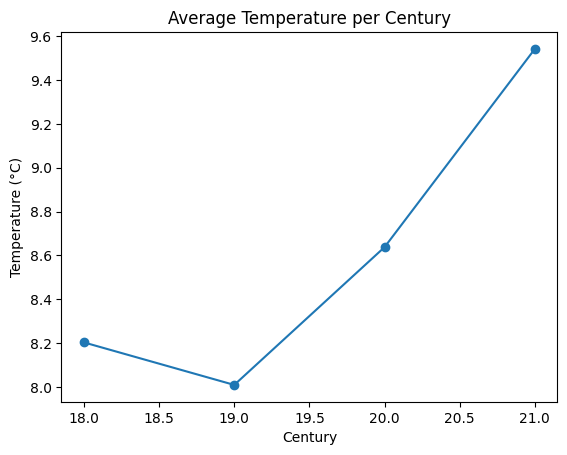

In [65]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(century_avg["century"], century_avg["LandAverageTemperature"], marker="o")

plt.title("Average Temperature per Century")
plt.xlabel("Century")
plt.ylabel("Temperature (°C)")

plt.show()

In [66]:
# Describe uncertainty columns
uncertainty_cols = [
    "LandAverageTemperatureUncertainty",
    "LandMaxTemperatureUncertainty",
    "LandMinTemperatureUncertainty",
    "LandAndOceanAverageTemperatureUncertainty"
]

print(df[uncertainty_cols].describe())

       LandAverageTemperatureUncertainty  LandMaxTemperatureUncertainty  \
count                        3180.000000                    1992.000000   
mean                            0.938468                       0.479782   
std                             1.096440                       0.583203   
min                             0.034000                       0.044000   
25%                             0.186750                       0.142000   
50%                             0.392000                       0.252000   
75%                             1.419250                       0.539000   
max                             7.880000                       4.373000   

       LandMinTemperatureUncertainty  \
count                    1992.000000   
mean                        0.431849   
std                         0.445838   
min                         0.045000   
25%                         0.155000   
50%                         0.279000   
75%                         0.458250   
max 

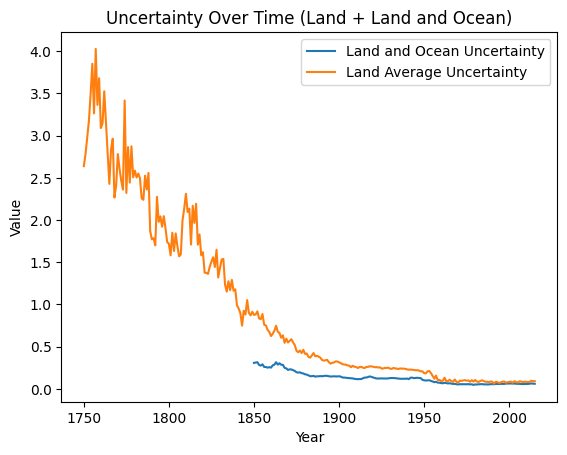

In [67]:
df["year"] = df["dt"].dt.year

trend = (
    df.groupby("year")[[
        "LandAndOceanAverageTemperatureUncertainty",
        "LandAverageTemperatureUncertainty"
    ]]
    .mean()
    .reset_index()
)

import matplotlib.pyplot as plt

plt.figure()

# Temperature line
plt.plot(
    trend["year"],
    trend["LandAndOceanAverageTemperatureUncertainty"],
    label="Land and Ocean Uncertainty"
)

# Uncertainty line
plt.plot(
    trend["year"],
    trend["LandAverageTemperatureUncertainty"],
    label="Land Average Uncertainty"
)

plt.title("Uncertainty Over Time (Land + Land and Ocean)")
plt.xlabel("Year")
plt.ylabel("Value")

plt.legend()
plt.show()

In [69]:
highest_uncertainty = trend.sort_values(
    "LandAverageTemperatureUncertainty", ascending=False
).head(10)

print(highest_uncertainty)

    year  LandAndOceanAverageTemperatureUncertainty  \
7   1757                                        NaN   
5   1755                                        NaN   
9   1759                                        NaN   
12  1762                                        NaN   
4   1754                                        NaN   
24  1774                                        NaN   
8   1758                                        NaN   
6   1756                                        NaN   
3   1753                                        NaN   
13  1763                                        NaN   

    LandAverageTemperatureUncertainty  
7                            4.026000  
5                            3.850333  
9                            3.678917  
12                           3.524250  
4                            3.494250  
24                           3.415167  
8                            3.362917  
6                            3.262333  
3                            3.176

In [70]:
def convert_coord(coord):
    coord = str(coord).strip()
    if coord[-1] in ["N", "E"]:
        return float(coord[:-1])
    elif coord[-1] in ["S", "W"]:
        return -float(coord[:-1])
    else:
        return None

df_city_subset["lat"] = df_city_subset["Latitude"].apply(convert_coord)
df_city_subset["lon"] = df_city_subset["Longitude"].apply(convert_coord)

In [75]:
city_avg = (
    df_city_subset.groupby(["City", "Country", "lat", "lon"])["AverageTemperature"]
    .mean()
    .reset_index()
)

In [72]:
import pandas as pd
import plotly.express as px

fig = px.scatter_geo(
    city_avg,
    lat="lat",
    lon="lon",
    color="AverageTemperature",
    hover_name="City",
    hover_data=["Country", "AverageTemperature"],
    title="Average Temperature per City",
    color_continuous_scale=["blue", "green", "red"]
)

fig.show()

In [76]:


top_hot_city = city_avg.sort_values("AverageTemperature", ascending=False).head(10)
top_cold_city = city_avg.sort_values("AverageTemperature", ascending=True).head(10)

top_hot_city["Type"] = "Hottest"
top_cold_city["Type"] = "Coldest"

extremes = pd.concat([top_hot_city, top_cold_city])

In [79]:
extremes_variable = pd.concat([top_variable, bottom_variable])

city_map = city_avg.merge(
    extremes_variable[["City", "range"]],
    on="City",
    how="inner"
)

In [83]:
def convert_lat(val):
    if isinstance(val, str):
        return float(val[:-1]) * (1 if val[-1] == "N" else -1)
    return val

def convert_lon(val):
    if isinstance(val, str):
        return float(val[:-1]) * (1 if val[-1] == "E" else -1)
    return val

city_map["lat"] = city_map["lat"].apply(convert_lat)
city_map["lon"] = city_map["lon"].apply(convert_lon)


fig = px.scatter_geo(
    city_map,
    lat="lat",
    lon="lon",
    color="range",  # 👈 THIS is the key change
    size="range",   # 👈 makes differences visible
    hover_name="City",
    hover_data=["City", "AverageTemperature", "range"],
    title="Temperature Range per City",
    color_continuous_scale="Viridis"
)

fig.show()

In [85]:
def convert_lat(val):
    if isinstance(val, str):
        return float(val[:-1]) * (1 if val[-1] == 'N' else -1)
    return val  # already numeric

def convert_lon(val):
    if isinstance(val, str):
        return float(val[:-1]) * (1 if val[-1] == 'E' else -1)
    return val  # already numeric

extremes["lat"] = extremes["lat"].apply(convert_lat)
extremes["lon"] = extremes["lon"].apply(convert_lon)

fig = px.scatter_geo(
    extremes,
    lat="lat",
    lon="lon",
    color="AverageTemperature",
    hover_name="City",
    hover_data=["City", "AverageTemperature"],
    title="Top 10 Hottest and Coldest Cities",
    color_continuous_scale=["blue", "green", "red"]
)

fig.show()

In [86]:
top_hot = country_avg.sort_values("AverageTemperature", ascending=False).head(10)
top_cold = country_avg.sort_values("AverageTemperature", ascending=True).head(10)

selected_countries = pd.concat([top_hot, top_cold])

fig = px.choropleth(
    selected_countries,
    locations="Country",
    locationmode="country names",
    color="AverageTemperature",
    hover_name="Country",
    title="Hottest and Coldest Countries",
    color_continuous_scale=["blue", "green", "red"]
)

fig.show()

/var/folders/10/rcqq4c4d7s9b5_358scx0wqh0000gn/T/ipykernel_21072/1867658377.py:6: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [87]:
# 👉 THIS is what you want
country_avg = (
    df_subset
    .groupby("Country")["AverageTemperature"]
    .mean()
    .reset_index()
)

print(country_avg)

            Country  AverageTemperature
0       Afghanistan           14.963869
1            Africa           24.690864
2           Albania           13.233686
3           Algeria           23.870874
4    American Samoa           27.107718
..              ...                 ...
238  Western Sahara           23.182146
239           Yemen           26.837510
240          Zambia           21.853948
241        Zimbabwe           21.695399
242           Åland            6.149498

[243 rows x 2 columns]


In [88]:
import plotly.express as px

fig = px.choropleth(
    country_avg,
    locations="Country",
    locationmode="country names",
    color="AverageTemperature",
    hover_name="Country",
    title="Average Temperature per Country (All Countries)",
    color_continuous_scale=["blue", "green", "red"]
)

fig.show()



/var/folders/10/rcqq4c4d7s9b5_358scx0wqh0000gn/T/ipykernel_21072/1308043973.py:3: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [89]:
import pandas as pd

df = pd.read_csv(
    "/Applications/XAMPP/xamppfiles/htdocs/climate-watch/co2 data/GHG_totals_by_country-Tabel 1.csv",
    sep=";",
    skiprows=1
)

# Fix weird column names
df.columns = df.columns.str.replace("\n", " ", regex=False).str.strip()

# Force correct names
df.columns = ["EDGAR Country Code", "Country"] + list(df.columns[2:])

# Melt (wide → long)
df_long = df.melt(
    id_vars=["Country"],
    var_name="year",
    value_name="co2"
)

# Clean values
df_long["year"] = pd.to_numeric(df_long["year"], errors="coerce")

df_long["co2"] = (
    df_long["co2"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df_long["co2"] = pd.to_numeric(df_long["co2"], errors="coerce")

# Filter years
df_long = df_long[df_long["year"] >= 1980]

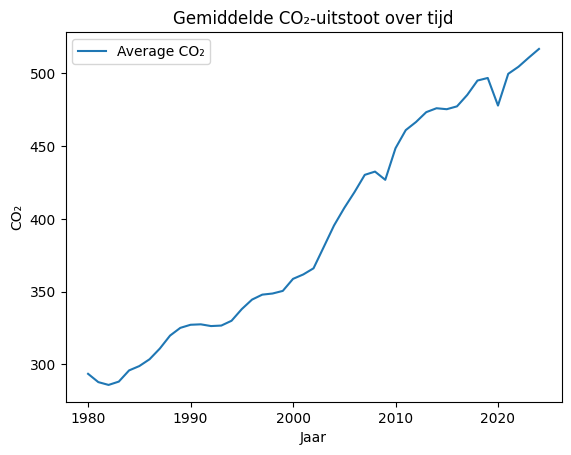

In [90]:
co2_yearly = (
    df_long
    .groupby("year")["co2"]
    .mean()
    .reset_index()
)

import matplotlib.pyplot as plt

plt.figure()

plt.plot(
    co2_yearly["year"],
    co2_yearly["co2"],
    label="Average CO₂"
)

plt.title("Gemiddelde CO₂-uitstoot over tijd")
plt.xlabel("Jaar")
plt.ylabel("CO₂")

plt.legend()
plt.show()

In [91]:
merged = yearly.merge(co2_yearly, on="year", how="inner")

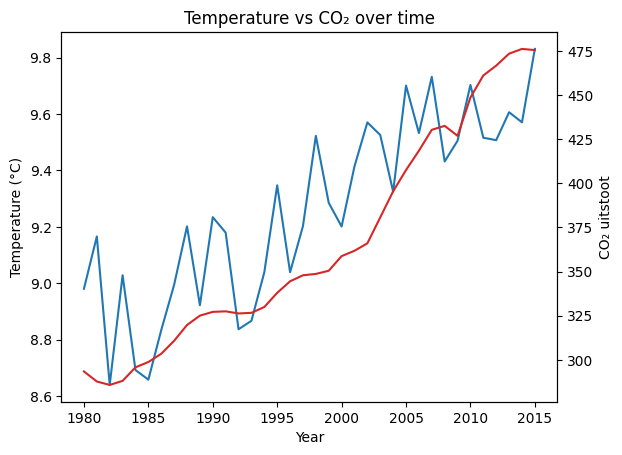

In [92]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

# Temperature (left axis)
ax1.plot(
    merged["year"],
    merged["LandAverageTemperature"],
    label="Temperature (°C)",
    color="tab:blue"
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Temperature (°C)")

# CO2 (right axis)
ax2 = ax1.twinx()
ax2.plot(
    merged["year"],
    merged["co2"],
    label="CO₂ uitstoot",
    color="tab:red"
)
ax2.set_ylabel("CO₂ uitstoot")

# Title
plt.title("Temperature vs CO₂ over time")

plt.show()

In [93]:
import pandas as pd

file_path = "/Applications/XAMPP/xamppfiles/htdocs/climate-watch/co2 data/PovStatsData 2.csv"

# Skip first title row, use row 2 as column names
df = pd.read_csv(
    file_path,
    sep=";",
    skiprows=1
)

# Clean country column
df["Country Name"] = df["Country Name"].astype(str).str.strip()

# Find Afghanistan
start_index = df[df["Country Name"] == "Afghanistan"].index[0]

# Keep from Afghanistan onward
df_clean = df.loc[start_index:].copy()
df_clean.reset_index(drop=True, inplace=True)

# Save cleaned CSV
df_clean.to_csv("cleaned_povstats.csv", index=False)

print(df_clean.head())
print(df_clean.columns)

  Country Name Country Code  \
0  Afghanistan          AFG   
1  Afghanistan          AFG   
2  Afghanistan          AFG   
3  Afghanistan          AFG   
4  Afghanistan          AFG   

                                      Indicator Name  Indicator Code  1974  \
0  Annualized growth in per capita real survey me...  SI.SPR.PC40.ZG   NaN   
1  Annualized growth in per capita real survey me...  SI.SPR.PT10.ZG   NaN   
2  Annualized growth in per capita real survey me...  SI.SPR.PT60.ZG   NaN   
3  Annualized growth in per capita real survey me...  SI.SPR.PCAP.ZG   NaN   
4                   GINI index (World Bank estimate)     SI.POV.GINI   NaN   

   1975  1976  1977  1978  1979  ...  2010  2011  2012  2013  2014  2015  \
0   NaN   NaN   NaN   NaN   NaN  ...   NaN   NaN   NaN   NaN   NaN   NaN   
1   NaN   NaN   NaN   NaN   NaN  ...   NaN   NaN   NaN   NaN   NaN   NaN   
2   NaN   NaN   NaN   NaN   NaN  ...   NaN   NaN   NaN   NaN   NaN   NaN   
3   NaN   NaN   NaN   NaN   NaN  ...   N

In [94]:
indicators = [
    "Poverty headcount ratio at $1.90 a day (2011 PPP) (% of population)",
    "GINI index (World Bank estimate)",
    "Number of poor at $1.90 a day (2011 PPP) (millions)"
]

df_filtered = df_clean[df_clean["Indicator Name"].isin(indicators)].copy()


In [95]:
df_long = df_filtered.melt(
    id_vars=["Country Name", "Indicator Name"],
    var_name="year",
    value_name="value"
)

In [96]:
df_long["value"] = (
    df_long["value"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .replace("..", pd.NA)
)

df_long["value"] = pd.to_numeric(df_long["value"], errors="coerce")

In [97]:
# Convert year to numeric
df_long["year"] = pd.to_numeric(df_long["year"], errors="coerce")

# Convert values to numeric
df_long["value"] = pd.to_numeric(df_long["value"], errors="coerce")

# Drop missing
df_long = df_long.dropna(subset=["year", "value"])

In [98]:
df_pivot = df_long.pivot_table(
    index=["Country Name", "year"],
    columns="Indicator Name",
    values="value"
).reset_index()

In [99]:
df_global = df_pivot.groupby("year", as_index=False).mean(numeric_only=True)

In [100]:
df_pivot["year"] = df_pivot["year"].astype(int)
df_global["year"] = df_global["year"].astype(int)

In [101]:
print(df_pivot.dtypes)

Indicator Name
Country Name                                                               str
year                                                                     int64
GINI index (World Bank estimate)                                       float64
Number of poor at $1.90 a day (2011 PPP) (millions)                    float64
Poverty headcount ratio at $1.90 a day (2011 PPP) (% of population)    float64
dtype: object


In [102]:
merged = yearly.merge(df_global, on="year", how="inner")

In [108]:
print(merged.head())
print(merged.columns)

   year  LandAverageTemperature  GINI index (World Bank estimate)  \
0  1977                8.850250                               NaN   
1  1979                8.733417                         39.866667   
2  1980                8.980333                         43.800000   
3  1981                9.165833                         44.800000   
4  1982                8.639167                         58.400000   

   Number of poor at $1.90 a day (2011 PPP) (millions)  \
0                                         410.200000     
1                                           0.433333     
2                                           2.050000     
3                                           5.385714     
4                                          27.600000     

   Poverty headcount ratio at $1.90 a day (2011 PPP) (% of population)  
0                                          61.600000                    
1                                           2.866667                    
2                

In [106]:
merged = merged.rename(columns={
    "AverageTemperature": "temperature"
})

In [109]:
merged.rename(columns={"LandAverageTemperature": "temperature"}, inplace=True)

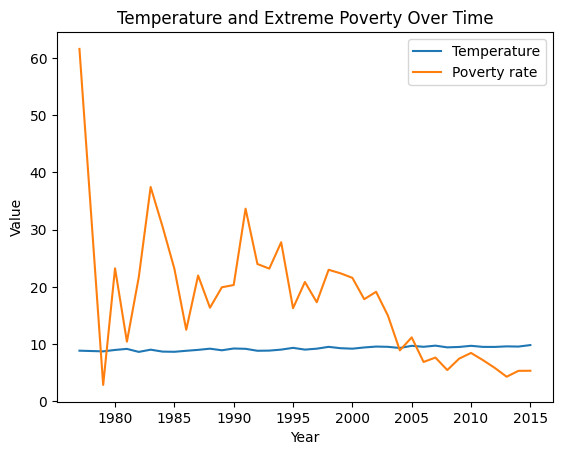

In [110]:
import matplotlib.pyplot as plt

poverty_col = "Poverty headcount ratio at $1.90 a day (2011 PPP) (% of population)"

plt.plot(merged["year"], merged["temperature"], label="Temperature")
plt.plot(merged["year"], merged[poverty_col], label="Poverty rate")

plt.title("Temperature and Extreme Poverty Over Time")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.show()